# Pick appropriate void-state thresholds for later denoising


You can improve some analyses' results by creating a binarized layer, which is also later used for binary activity score.

This notebook also includes code for checking correlation between replicates/timepoints.

In [1]:
import sys
import numpy as np
import anndata as ad
import pickle

# Hack to get to src folder (this notebook is in notebooks/shared)
sys.path.insert(0, '..')

import src as scit
import anndata as ad
import polars as pl

In [5]:
adata = ad.read_h5ad('private/data/marek/combined.h5ad')

lc_acet = scit.tl.make_layer_config("acet", log_transform=True, normalize_with_obs_counts=True)
lc_meth = scit.tl.make_layer_config("meth", log_transform=True, normalize_with_obs_counts=True)
lc_atac = scit.tl.make_layer_config("ATAC", log_transform=True, normalize_with_obs_counts=True)

Info: Passing entries (> 0): 48279966 (100.00%)


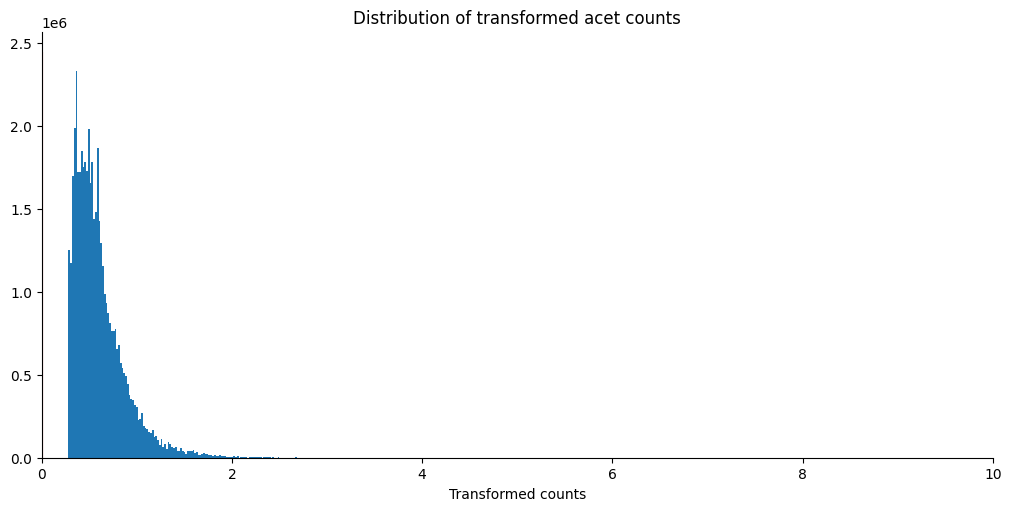

Info: Passing entries (> 0): 19489811 (100.00%)


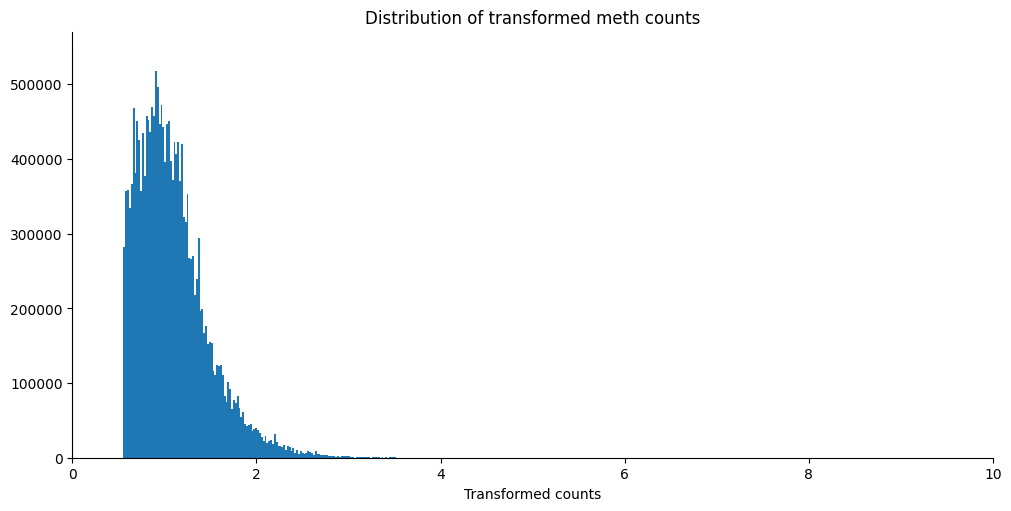

Info: Passing entries (> 0): 15742784 (100.00%)


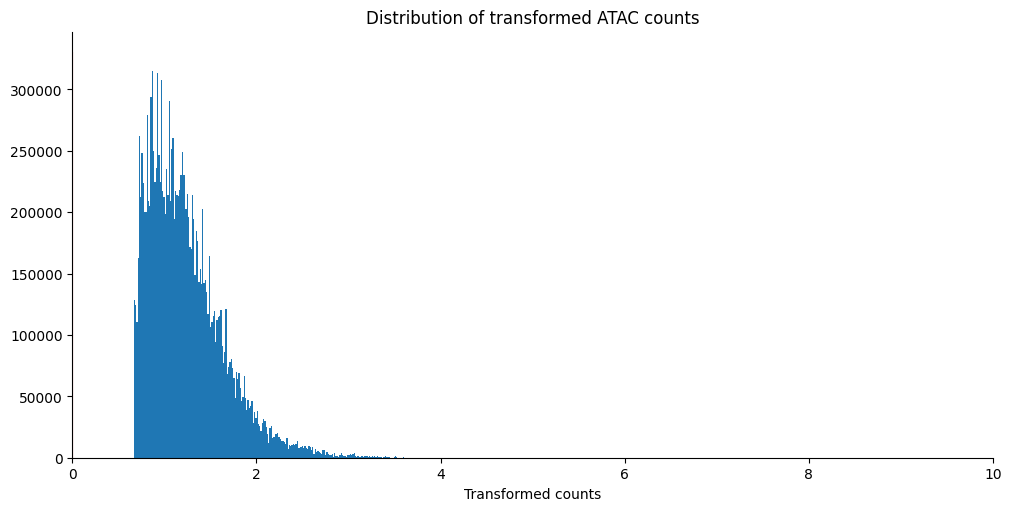

In [6]:
# Visualize bin total counts

scit.pl.layer_config_histogram(adata, lc_acet, bins=200, threshold=0,xminmax=(0,10), total_counts=False)
scit.pl.layer_config_histogram(adata, lc_meth, bins=200,threshold=0, xminmax=(0,10), total_counts=False)
scit.pl.layer_config_histogram(adata, lc_atac, bins=300,threshold=0, xminmax=(0,10), total_counts=False)

In [11]:
# Pick thresholds for removing low-quality reads (they will be binarized)
# Thresholds are after all transformations

transforms = {
    "idf_transform": True,
    "log_transform": True,
    "normalize_with_l2_norm": True,
}
# transforms = {
#     "normalize_with_obs_counts": True,
#     "log_transform": True,
#     "feature_names": adata.var_names
# }

# Pick appropriate thresholds
lc_acet = scit.tl.make_layer_config(
    'acet',
    feature_active_threshold=4,#2.5,#
    **transforms
)
lc_meth = scit.tl.make_layer_config(
    'meth',
    feature_active_threshold=4,#2.5,#
    **transforms
)

Info: Passing entries (> 4): 40727843 (84.36%)


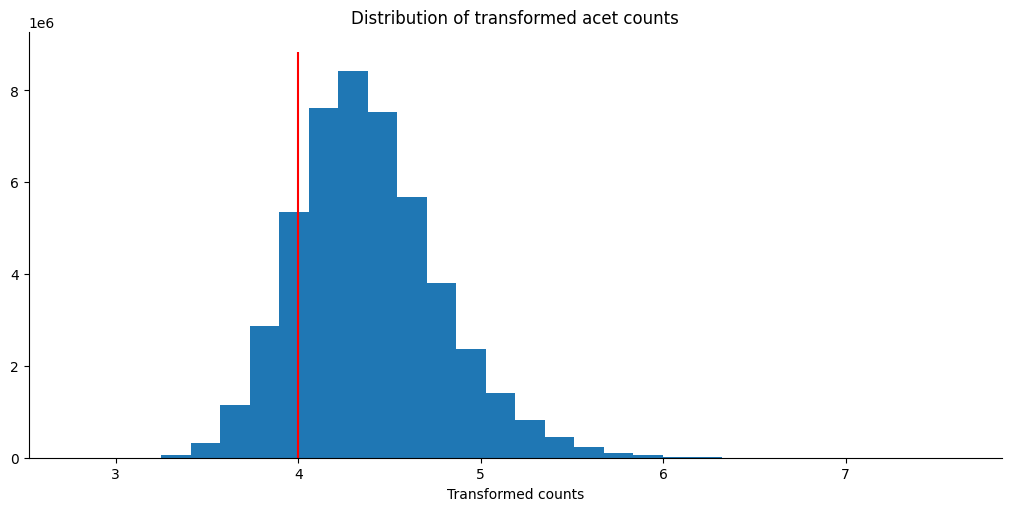

Info: Passing entries (> 4): 18806009 (96.49%)


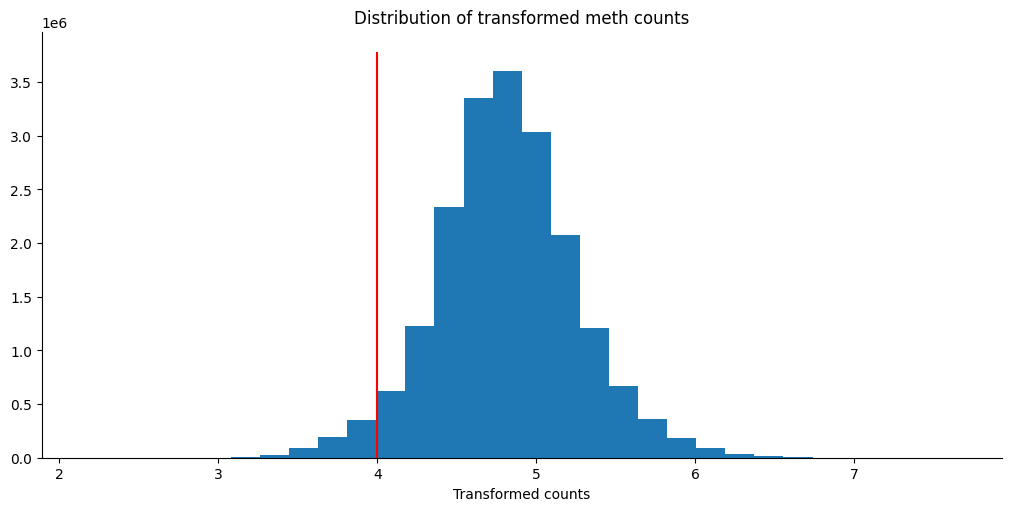

In [12]:
# Histograms for read data (not per-feature, but all recorded data from the sparse matrix)

scit.pl.layer_config_histogram(adata, lc_acet)
scit.pl.layer_config_histogram(adata, lc_meth)

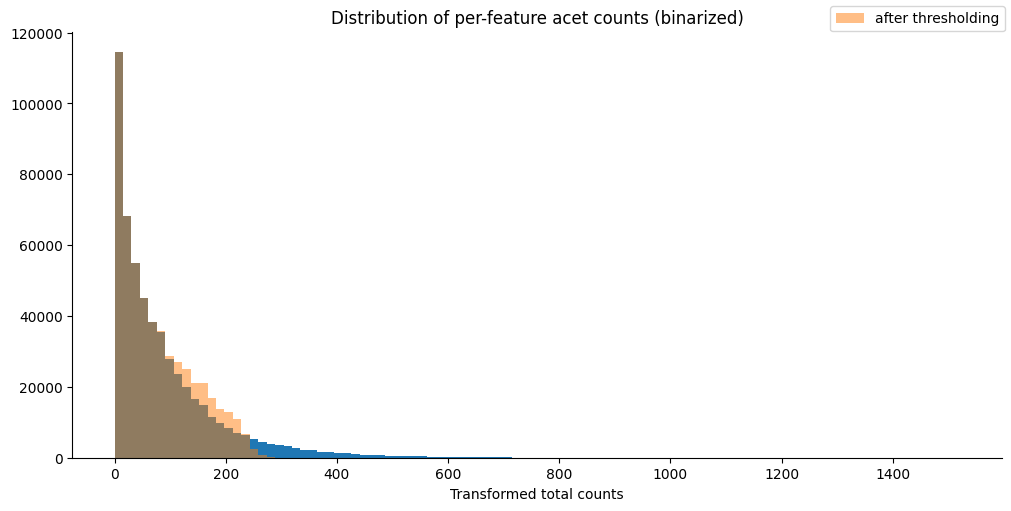

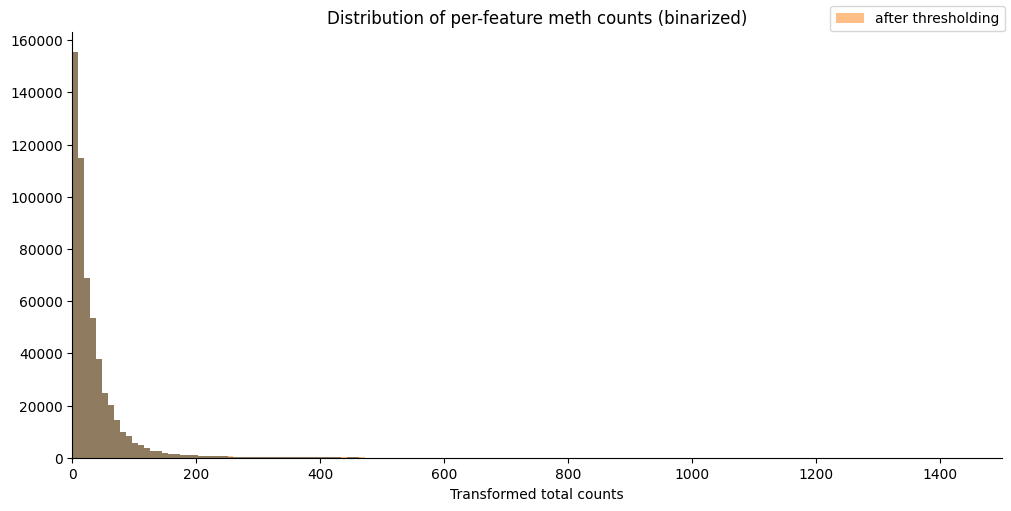

In [13]:
# Visualize per-feature total count binarized counts, with and without threshold to see how thresholding affects the data

scit.pl.layer_config_histogram(adata, lc_acet, total_counts=True, after_binarization=True, bins=100)
scit.pl.layer_config_histogram(adata, lc_meth, total_counts=True, after_binarization=True, bins=300, xminmax=(0, 1500))

In [21]:
# Exclude genes below potential threshold
# 1% of cells needs to have signal

potential_th = int(adata.shape[0] * 0.02)
print(potential_th)

88


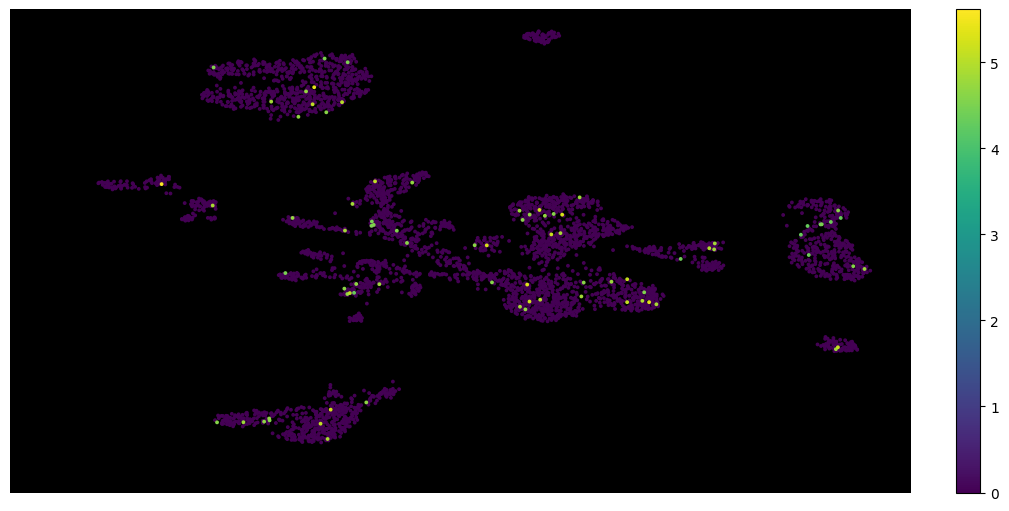

In [22]:
scit.tl.layer_pick_features(adata, lc_meth, after_binarization = True, filter_max = potential_th, filter_min = potential_th - 10)

# Pick a random bin to check if it really should be excluded,
# if not, adjust the potential threshold above to be more strict/lenient
no_pass = np.arange(lc_meth.get_shape(adata)[1])[lc_meth.cached_mask]
scit.tl.layer_pick_features(adata, lc_meth, no_pass[2])

# Check if these are the features you want to exclude
scit.tl.copy_to_obs(adata, lc_meth)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', black_background=True)


In [23]:
adata.layers['meth_binary'] = lc_meth.transform(adata, binarize=True)
adata.layers['acet_binary'] = lc_acet.transform(adata, binarize=True)

In [24]:
adata.write_h5ad('private/data/marek/combined.h5ad')

In [3]:
adata = ad.read_h5ad('private/data/marek/combined.h5ad')

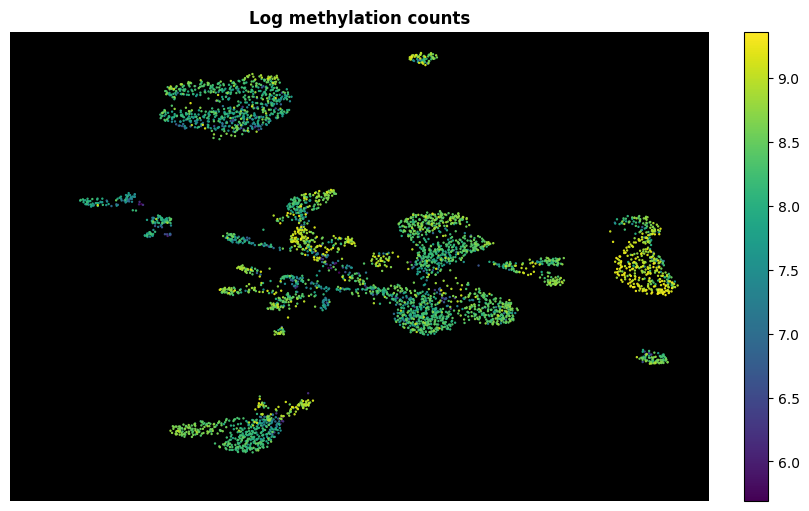

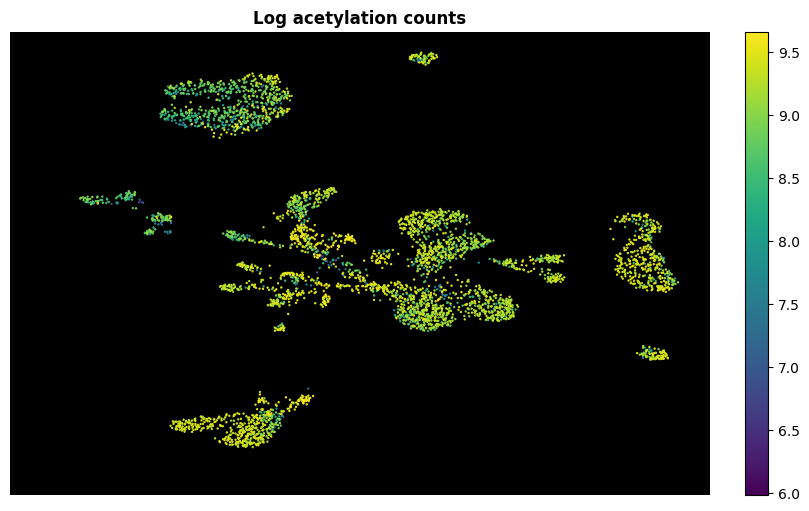

In [25]:
scit.tl.add_metadata(adata, var_loc_metadata=False)
scit.set_defaults(figsize=(8,5))
scit.pl.embedding2d(adata, 'X_umap', 'meth_binary_log_total_counts', title='Log methylation counts', size=0.5, black_background=True)
scit.pl.embedding2d(adata, 'X_umap', 'acet_binary_log_total_counts', title='Log acetylation counts', size=0.5, black_background=True)

9231


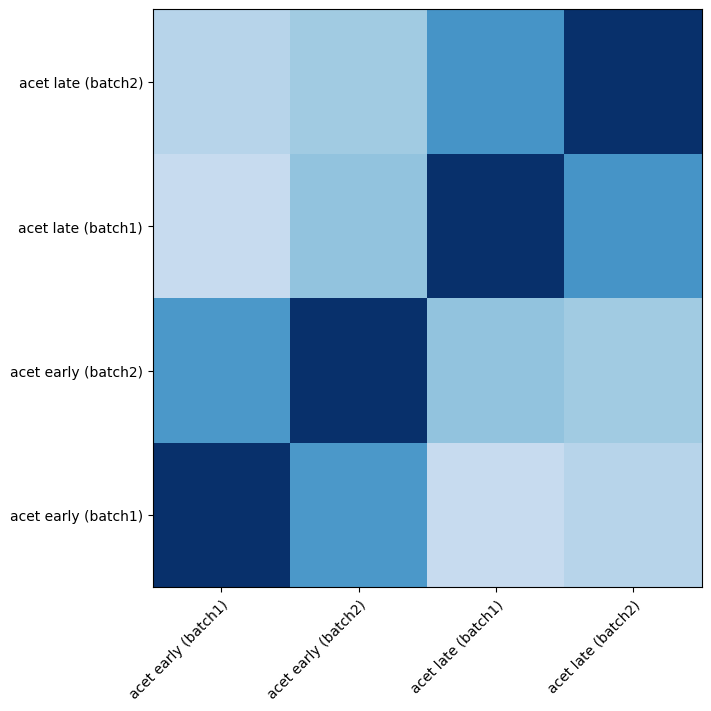

In [45]:
# Compare replicates
# If you don't have replicates / different timepoints,
# You cannot run this code

lc_acet = scit.tl.make_layer_config('acet_binary')
scit.tl.layer_pick_features(adata, lc_acet, filter_min=450)
X = lc_acet.transform(adata, use_cached_mask=True)


df = adata.obs.copy()
masks = [None, None]
early = [None, None]
masks[0] = df.batch == 'batch1'
masks[1] = df.batch == 'batch2'
early[0] = df[masks[0]].timep == '8_10h'
early[1] = df[masks[1]].timep == '8_10h'

allrow = np.array([
    X[masks[0]][early[0]].sum(axis=0).A1,
    X[masks[1]][early[1]].sum(axis=0).A1,
    X[masks[0]][~early[0]].sum(axis=0).A1,
    X[masks[1]][~early[1]].sum(axis=0).A1
]).T
import scipy.stats as sts
corrs = sts.spearmanr(allrow, axis=0).statistic
scit.set_defaults(figsize=(7,7))
scit.pl.custom_heatmap(
    corrs,
    ['acet early (batch1)', 'acet early (batch2)', 'acet late (batch1)', 'acet late (batch2)'],
    vminmax=(0,1),
    square_matrix=True
)
